In [5]:
import requests
import warnings
warnings.filterwarnings("ignore", message=".*_register_pytree_node is deprecated.*")
import torch
from PIL import Image
from pathlib import Path
from mlmamba import load
import matplotlib.pyplot as plt

print("start load ML-Mamba model.")

# Read the Hugging Face token
hf_token = Path(".hf_token").read_text().strip()

# Set the device and dtype
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# Load the pretrained VLM
model_id = "mlmamba+3b"
vlm = load(model_id, hf_token=hf_token)
vlm.to(device, dtype=dtype)

print("load ML-Mamba model complete.")

start load ML-Mamba model.


08/18 [20:39:17] INFO     | >> [*] Downloading `mlmamba+3b from HF Hub                                   ]8;id=616500;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py\load.py]8;;\:]8;id=652348;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py#61\61]8;;\

                 INFO     | >> [*] Found Config =>> Loading & Freezing mlmamba+3b with:                  ]8;id=482475;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py\load.py]8;;\:]8;id=916286;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py#87\87]8;;\
                                       Vision Backbone =>> dinosiglip-vit-so-384px                                 
                                       LLM Backbone    =>> mamba2-2.7b                                             
                                       Arch Specifier  =>> no-align+fused-gelu-mlp                                 
                                                                                                                   

                 INFO     | >> [*] Loading Pretrained LLM mamba2-2.7b via HF Transformers                ]8;id=973533;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py\load.py]8;;\:]8;id=53228;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py#96\96]8;;\

                 INFO     | >>     |=> Building empty mamba2 LLM from `state-spaces/mamba2-2.7b`    ]8;id=875148;file:///home/hwj/program/ML-Mamba/mlmamba/models/backbones/llm/base_llm.py\base_llm.py]8;;\:]8;id=77901;file:///home/hwj/program/ML-Mamba/mlmamba/models/backbones/llm/base_llm.py#132\132]8;;\

...

                 INFO     | >> Resized position embedding: (37, 37) to (27, 27).                    ]8;id=497636;file:///home/hwj/.local/lib/python3.10/site-packages/timm/layers/pos_embed.py\pos_embed.py]8;;\:]8;id=388268;file:///home/hwj/.local/lib/python3.10/site-packages/timm/layers/pos_embed.py#55\55]8;;\

08/18 [20:39:38] INFO     | >> Loading pretrained weights from Hugging Face hub                     ]8;id=626886;file:///home/hwj/.local/lib/python3.10/site-packages/timm/models/_builder.py\_builder.py]8;;\:]8;id=991591;file:///home/hwj/.local/lib/python3.10/site-packages/timm/models/_builder.py#187\187]8;;\
                          (('timm/ViT-SO400M-14-SigLIP-384', 'open_clip_pytorch_model.bin'))                       

                 INFO     | >>  Safe alternative available for 'open_clip_pytorch_model.bin' (as        ]8;id=573953;file:///home/hwj/.local/lib/python3.10/site-packages/timm/models/_hub.py\_hub.py]8;;\:]8;id=658473;file:///home/hwj/.local/lib/python3.10/site-packages/timm/models/_hub.py#180\180]8;;\
                          'open_clip_model.safetensors'). Loading weights using safetensors.                       

08/18 [20:39:39] INFO     | >> [*] Loading VLM mlmamba+3b from Checkpoint; Freezing Weights 🥶          ]8;id=476764;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py\load.py]8;;\:]8;id=169891;file:///home/hwj/program/ML-Mamba/mlmamba/models/load.py#113\113]8;;\

load ML-Mamba model complete.


In [6]:
# 图片文件名列表
image_files = [
    'test0.png', 'test1.png', 'test2.png', 'test3.png', 
    'test4.png', 'test5.png', 'test6.png'
]

# 用户提示列表
user_prompts = [
    "Provide a detailed description of this image",
    "Is the bicycle parked on the right side of the dog?",
    "What's unusual about this photo?",
    "What should I pay attention to when I come here?",
    "Can I swim here?",
    "What's going on in this picture?",
    "What's going on in this picture?"
]

# 生成参数
generate_params = {
    'use_cache': True,
    'do_sample': True,
    'temperature': 1.0,
    'max_new_tokens': 256
}

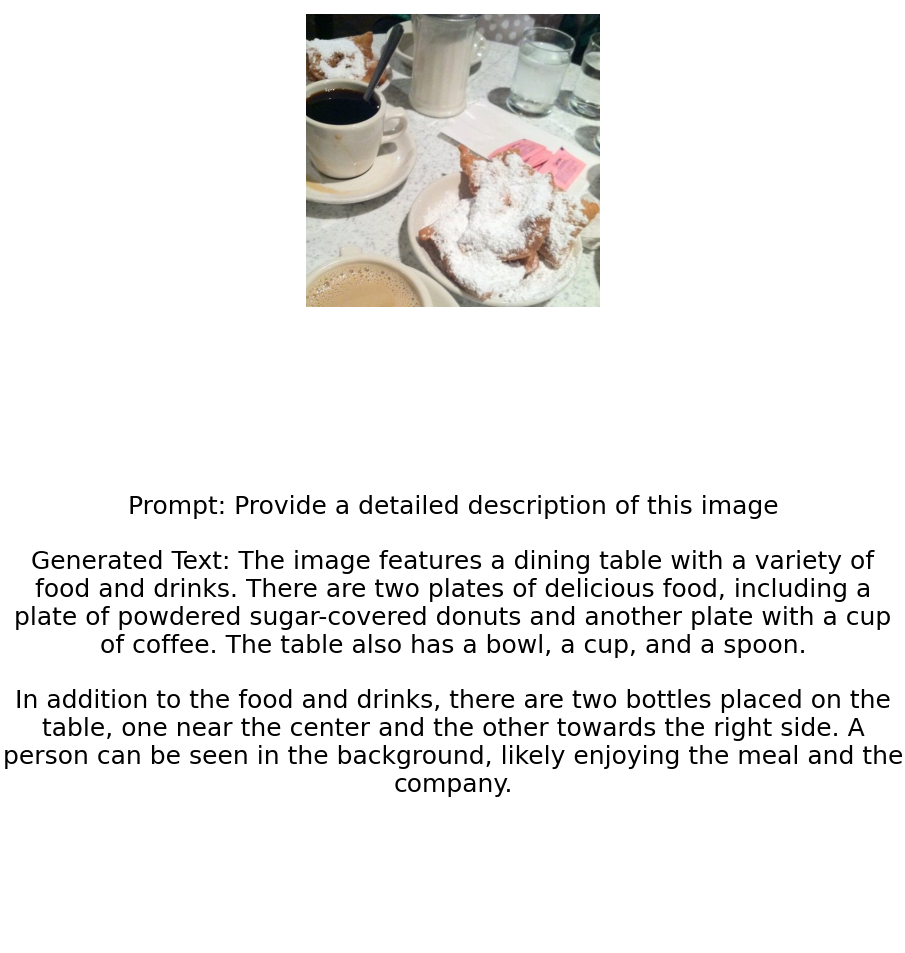

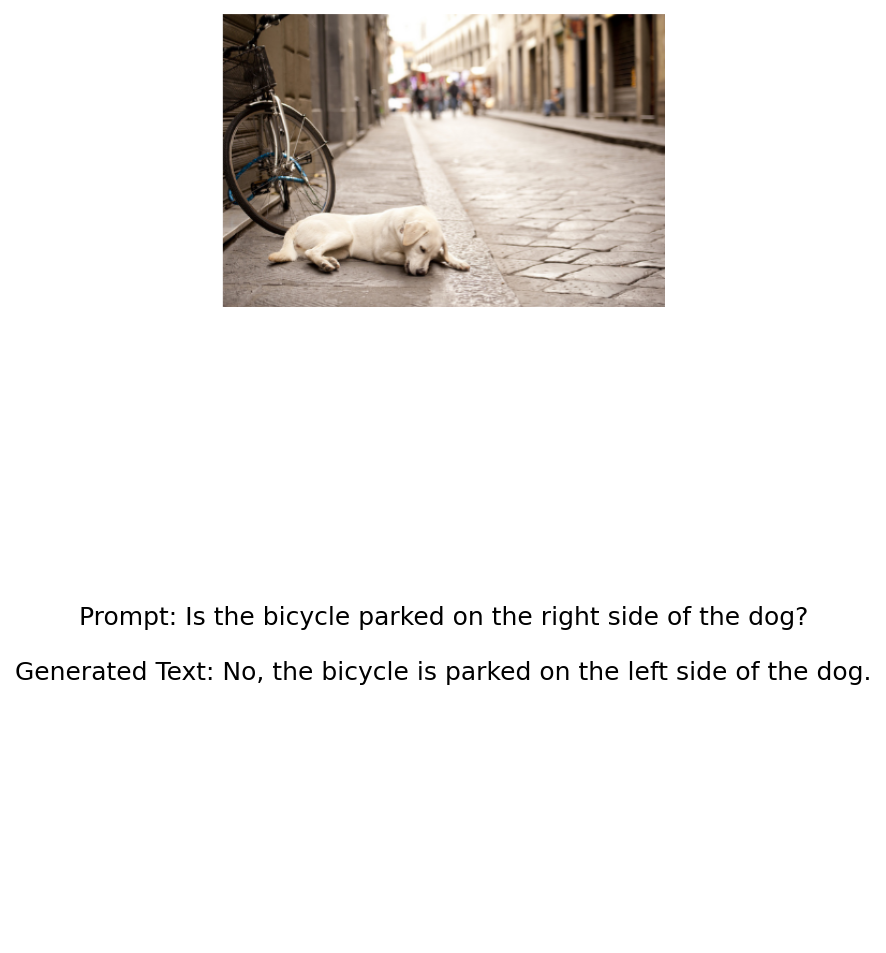

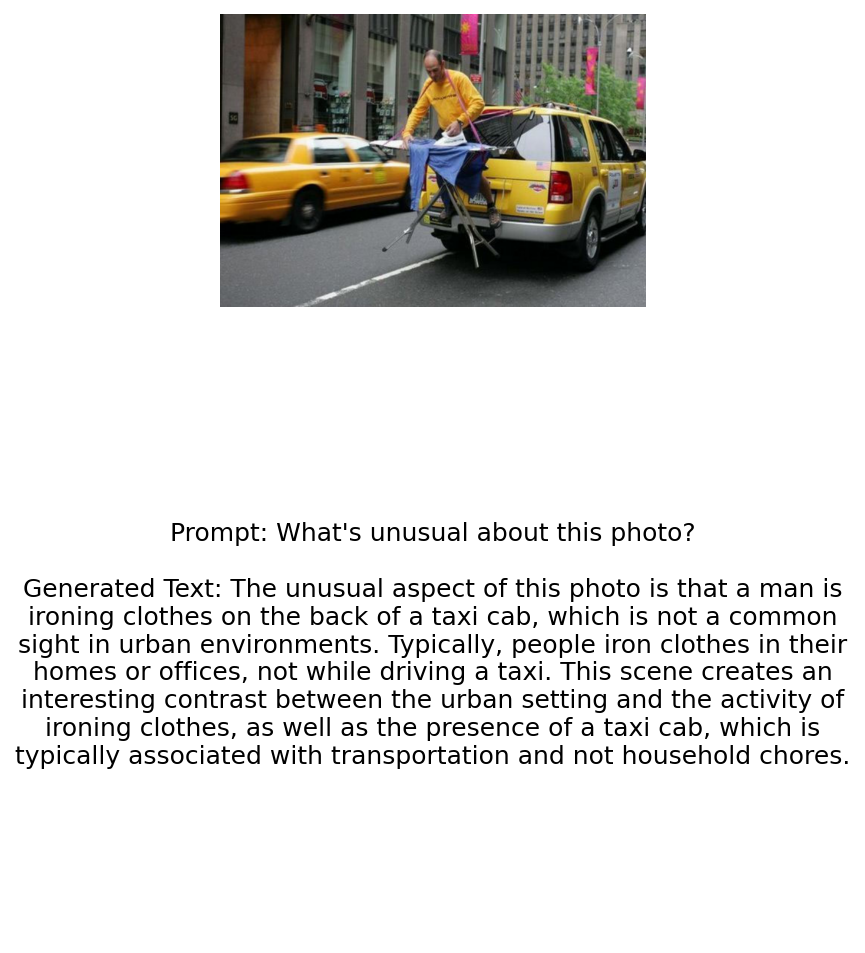

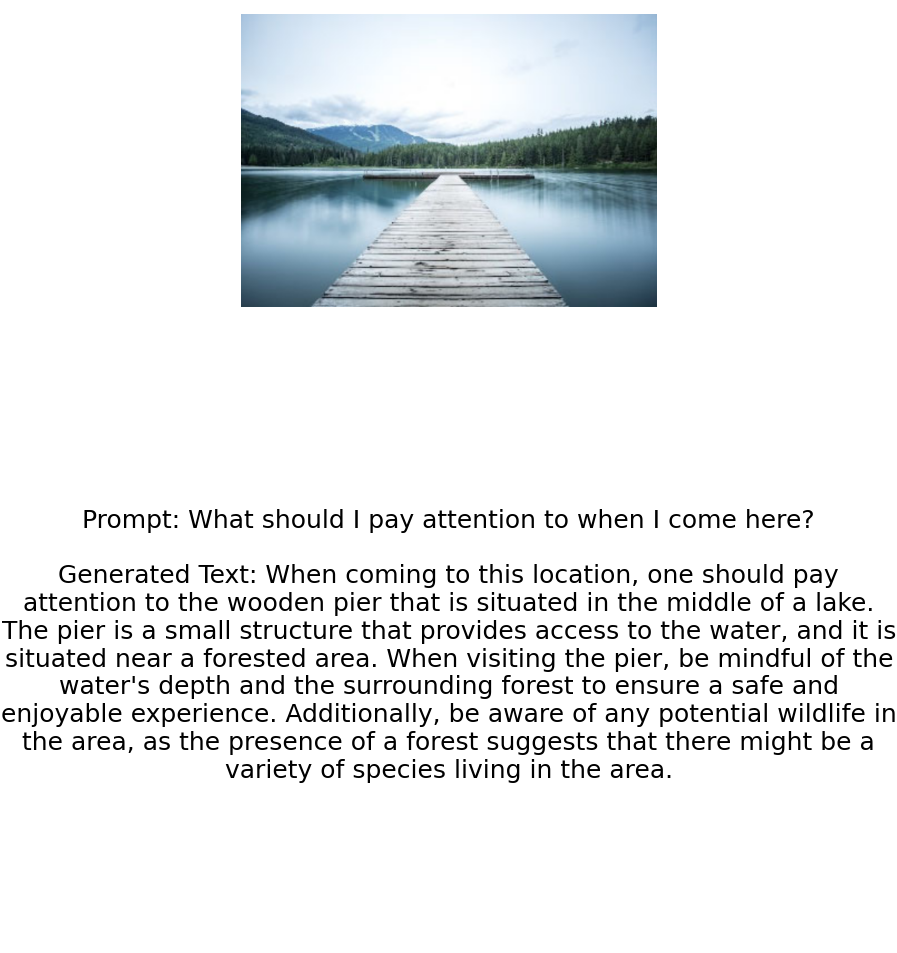

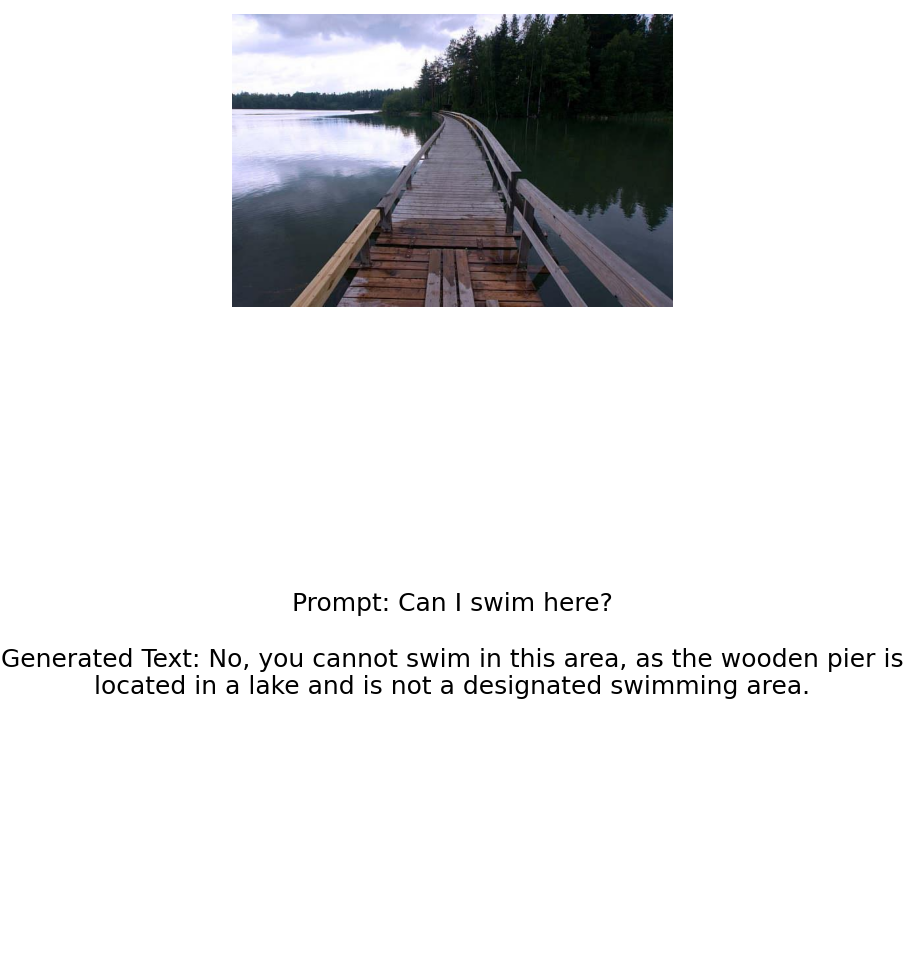

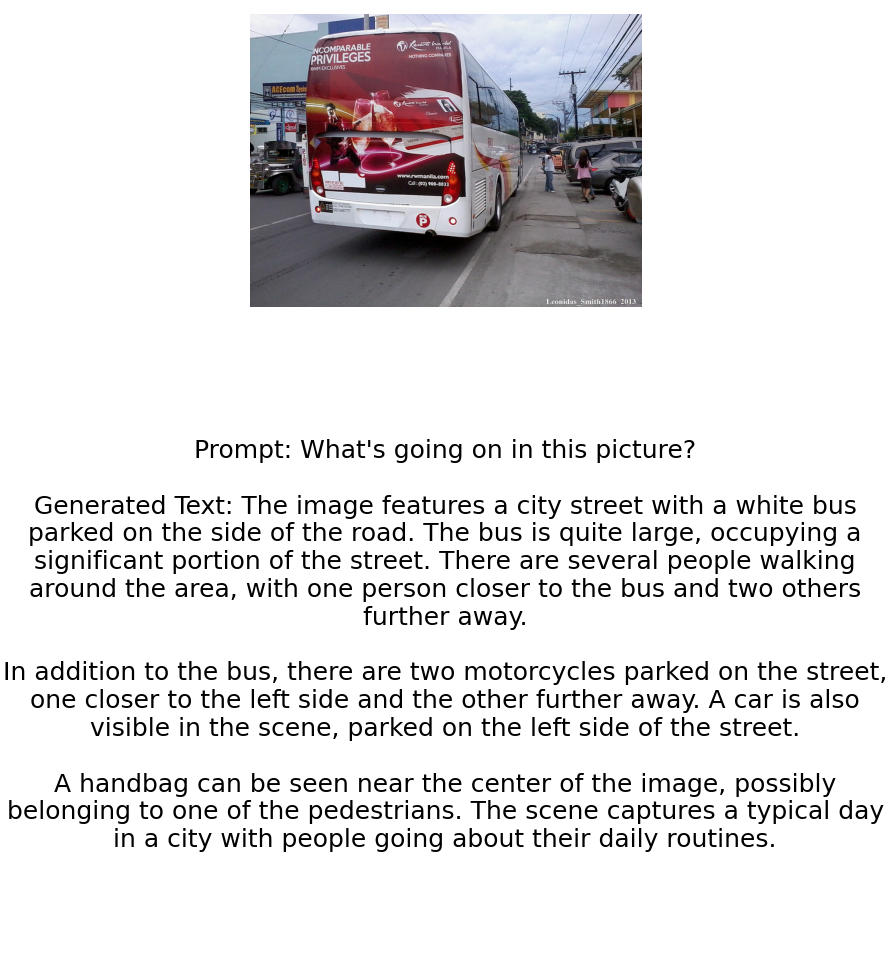

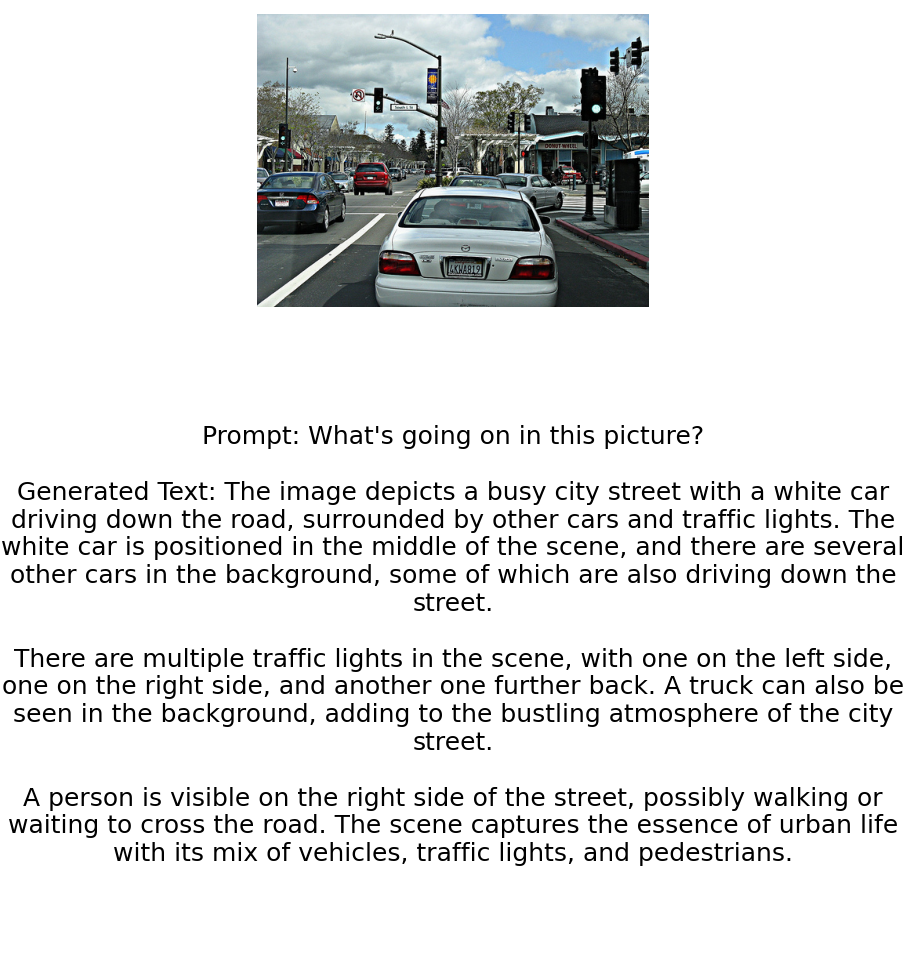

In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

# 设置统一的图片大小
desired_size = (150, 150)  # 你可以根据需要调整大小

for image_file, user_prompt in zip(image_files, user_prompts):
    # 打开并转换图像
    image = Image.open("pic/" + image_file).convert("RGB")
    
    # 调整图片大小
    #image = image.resize(desired_size, Image.LANCZOS)

    # 创建prompt
    prompt_builder = vlm.get_prompt_builder()
    prompt_builder.add_turn(role="human", message=user_prompt)
    prompt_text = prompt_builder.get_prompt()

    # 更新生成参数
    generate_params['image'] = image
    generate_params['prompt_text'] = prompt_text

    # 生成文本
    generated_text = vlm.generate(**generate_params)

    # 创建一个新的图形和子图
    fig = plt.figure(figsize=(6, 8), dpi=150)  # 设置DPI以提高清晰度
    gs = GridSpec(2, 1, height_ratios=[1, 2])  # 设置子图的相对高度

    # 在第一个子图中显示图像
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(image)
    ax0.axis('off')

    # 在第二个子图中显示问题和生成的文本
    ax1 = fig.add_subplot(gs[1])
    text = f"Prompt: {user_prompt}\n\nGenerated Text: {generated_text}"
    ax1.text(0.5, 0.5, text, ha='center', va='center', fontsize=12, wrap=True)
    ax1.axis('off')

    # 调整子图之间的间距，使得文字紧挨着图片
    plt.subplots_adjust(hspace=0.1)

    # 显示图形
    plt.show()
